# Lojistik Regresyon

Bu notebook, lojistik regresyon algoritmasının sınıflandırma problemlerinde nasıl kullanıldığını göstermektedir. MNIST veri setinden seçilen 3 ve 7 rakamlarını sınıflandırmak için bir ikili sınıflandırma modeli oluşturacağız.

Lojistik regresyon, doğrusal regresyondan farklı olarak bir sınıflandırma algoritmasıdır ve sigmoid fonksiyonu kullanarak olasılık değerleri üretir.

İlk olarak, gerekli kütüphaneyi yükleyelim:

```
!pip install idx2numpy
```

Not: Yukarıdaki komutu sadece ilgili kütüphane kurulu değilse çalıştırın.

In [7]:
import numpy as np
import idx2numpy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## MNIST Veri Seti

MNIST veri seti, el yazısı rakamların bir koleksiyonudur ve makine öğrenmesi alanında bir "Merhaba Dünya" örneği olarak kabul edilir. Bu veri seti, 60,000 eğitim örneği ve 10,000 test örneği içerir.

Eğer veri seti lokal olarak mevcut değilse, aşağıdaki komutları kullanarak indirebilirsiniz:

### MNIST veri seti indirme komutları

```bash
!wget https://github.com/ihpar/ibu_cv/raw/main/mnist/m_nist.zip
!unzip /content/m_nist.zip -d m_nist
```

Not: Bu komutlar sadece veri seti henüz indirilmemişse çalıştırılmalıdır.

MNIST veri setinin bulunduğu dizini belirtelim:

In [8]:
MNIST_DIR = "mnist/"

## Veri Yükleme

MNIST veri setini özel IDX formatından NumPy dizilerine dönüştürelim. `idx2numpy` kütüphanesi, IDX formatındaki dosyaları NumPy dizilerine dönüştürmemize yardımcı olur.

In [9]:
train_arr = idx2numpy.convert_from_file(MNIST_DIR + "train-images-idx3-ubyte")
train_labels = idx2numpy.convert_from_file(
    MNIST_DIR + "train-labels-idx1-ubyte")

## Veri Keşfi

Yüklediğimiz verilerin boyutlarını kontrol edelim. Eğitim veri setimiz 60,000 görüntü içermeli ve her bir görüntü 28x28 piksel olmalıdır.

In [10]:
print(train_arr.shape, train_labels.shape)

(60000, 28, 28) (60000,)


Piksel değerlerinin aralığını kontrol edelim. MNIST veri setindeki piksel değerleri genellikle 0-255 arasındadır.

In [11]:
print(np.min(train_arr), np.max(train_arr))

0 255


Veri setindeki ilk görüntüyü görselleştirelim:

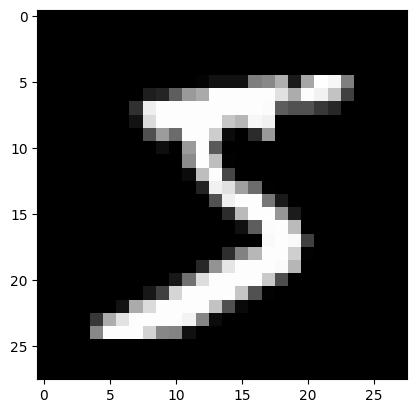

In [12]:
plt.imshow(train_arr[0], cmap="gray")
plt.show()

İlk birkaç etiketin değerlerini kontrol edelim:

In [13]:
train_labels[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

## Veri Ön İşleme

### Görüntüleri Düzleştirme (Flattening)

Lojistik regresyon modeli için, 2 boyutlu görüntüleri 1 boyutlu vektörlere dönüştürmemiz gerekiyor. Her 28x28 piksellik görüntüyü 784 elemanlı bir vektöre düzleştireceğiz.

In [14]:
X_train = train_arr.reshape(60000, -1)
X_train.shape

(60000, 784)

Düzleştirmenin doğru çalışıp çalışmadığını kontrol etmek için, düzleştirilmiş bir görüntüyü tekrar 28x28 boyutuna dönüştürüp görselleştirelim:

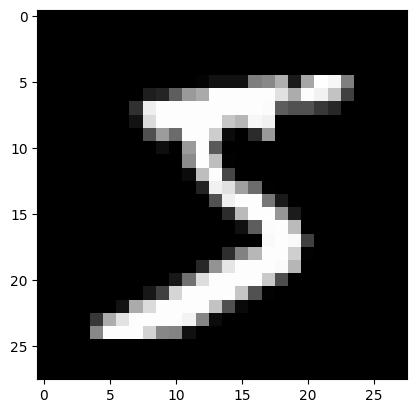

In [15]:
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.show()

### Normalizasyon

Piksel değerlerini 0-1 aralığına normalize edelim. Bu, modelin daha hızlı ve kararlı bir şekilde eğitilmesine yardımcı olacaktır.

In [16]:
X_train = X_train / 255.0

Normalizasyonun ardından görseli tekrar kontrol edelim:

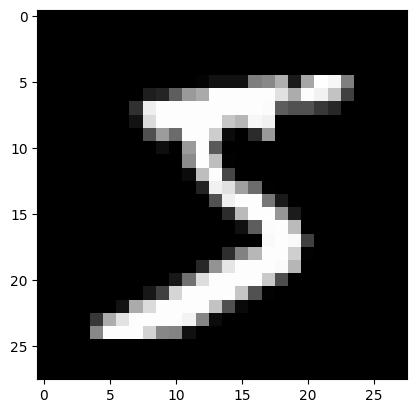

In [17]:
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.show()

### Etiketleri Hazırlama

Etiketleri (y) bir numpy dizisine kopyalayalım:

In [18]:
y_train = np.copy(train_labels)

Veri setinden ilk 9 örneği görselleştirelim ve etiketlerini gösterelim:

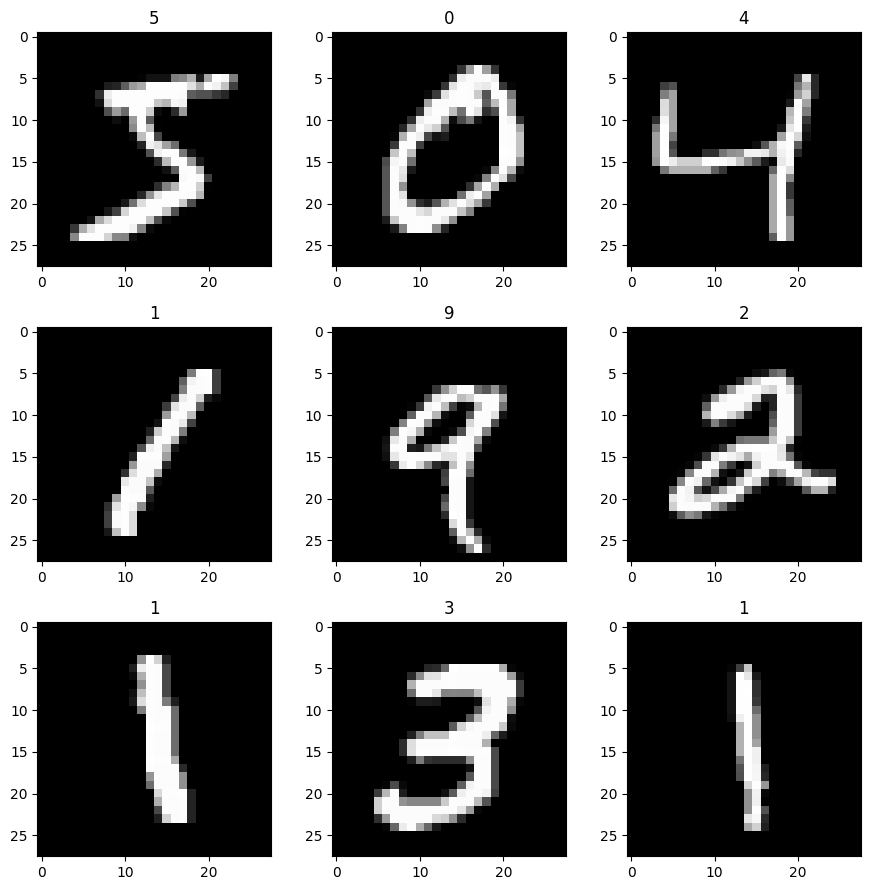

In [19]:
plt.figure(figsize=(9, 9))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.title(str(y_train[i]))
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")

plt.tight_layout()
plt.show()

## Özel Veri Seti Oluşturma

Veri setini 0'dan 9'a kadarki rakamlar yerine sadece 3 ve 7'ye indirgeyeceğiz.<br>
Eğer resimde 3 yazısı varsa karşılığı 0; 7 yazısı varsa karşılığı 1 olacak.

Bu, problemimizi 10 sınıflı (çok sınıflı sınıflandırma) bir problemden 2 sınıflı (ikili sınıflandırma) bir probleme dönüştürecektir.

### 3 Rakamlarını Filtreleme

Sadece 3 rakamı içeren örnekleri seçelim:

In [20]:
X_3 = X_train[y_train == 3]

In [41]:
X_3.shape

(6131, 784)

Filtrelediğimiz 3 rakamlarından bazı örnekleri görselleştirelim:

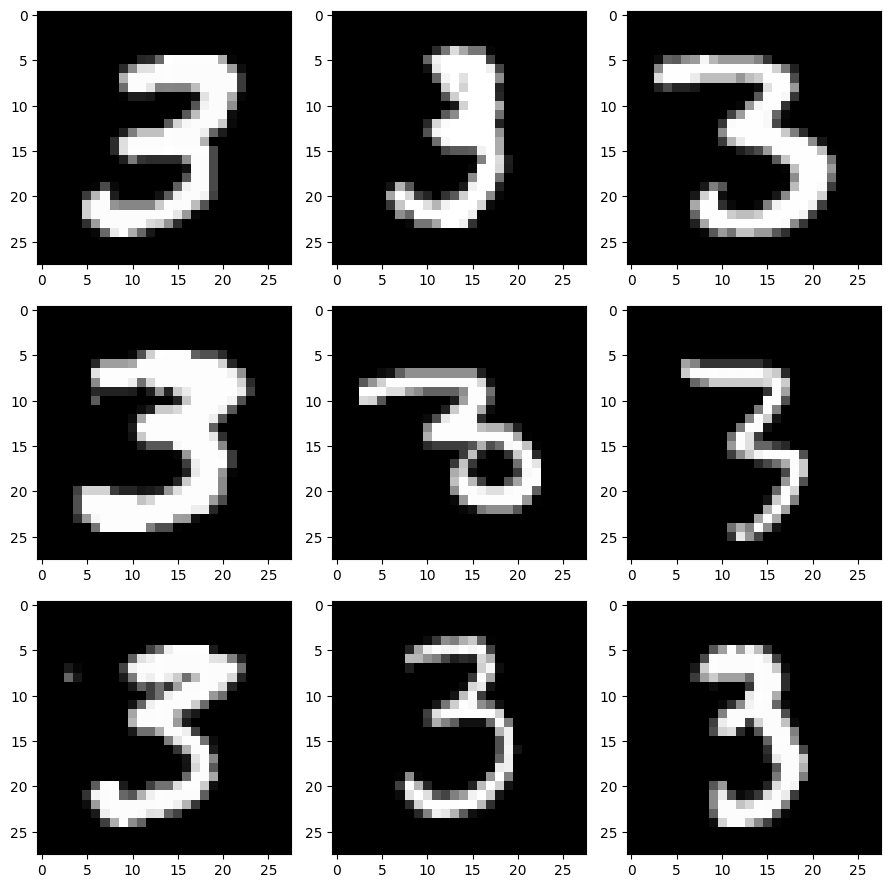

In [22]:
plt.figure(figsize=(9, 9))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_3[i].reshape(28, 28), cmap="gray")

plt.tight_layout()
plt.show()

### 7 Rakamlarını Filtreleme

Şimdi de 7 rakamı içeren örnekleri seçelim:

In [23]:
X_7 = X_train[y_train == 7]
X_7.shape

(6265, 784)

Filtrelediğimiz 7 rakamlarından bazı örnekleri görselleştirelim:

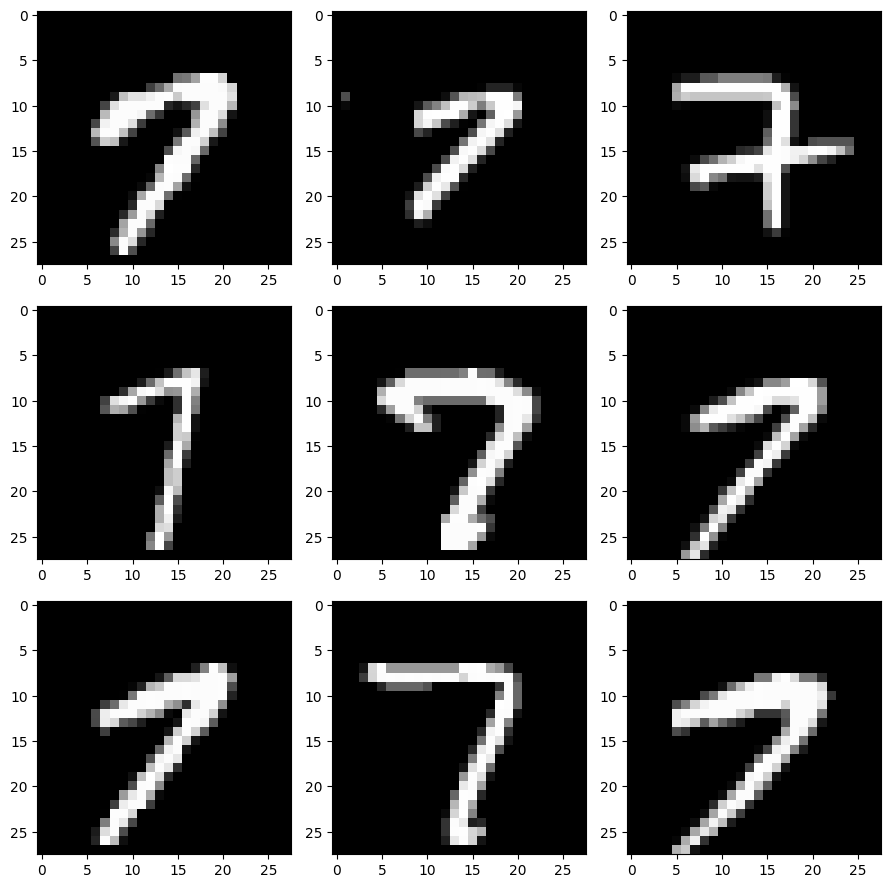

In [24]:
plt.figure(figsize=(9, 9))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_7[i].reshape(28, 28), cmap="gray")

plt.tight_layout()
plt.show()

### İkili Etiketleri Oluşturma

Lojistik regresyon için ikili etiketler oluşturacağız:
- 3 rakamı için etiket: 0
- 7 rakamı için etiket: 1

In [25]:
y_3 = np.zeros(X_3.shape[0])

In [26]:
y_7 = np.ones(X_7.shape[0])

Oluşturduğumuz etiketleri kontrol edelim:

In [27]:
print(y_3[:5])
print(y_7[:5])

[0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1.]


### Veri Setlerini Birleştirme

3 ve 7 rakamlarını içeren veri setlerini birleştirelim:

In [28]:
X_train_subset = np.append(X_3, X_7, axis=0)

In [29]:
X_train_subset.shape

(12396, 784)

In [30]:
y_train_subset = np.append(y_3, y_7)

In [31]:
y_train_subset.shape

(12396,)

Birleştirilmiş veri setini farklı indekslerde kontrol edelim. İlk indeksler 3 rakamlarını (etiket 0), sonraki indeksler 7 rakamlarını (etiket 1) içermelidir:

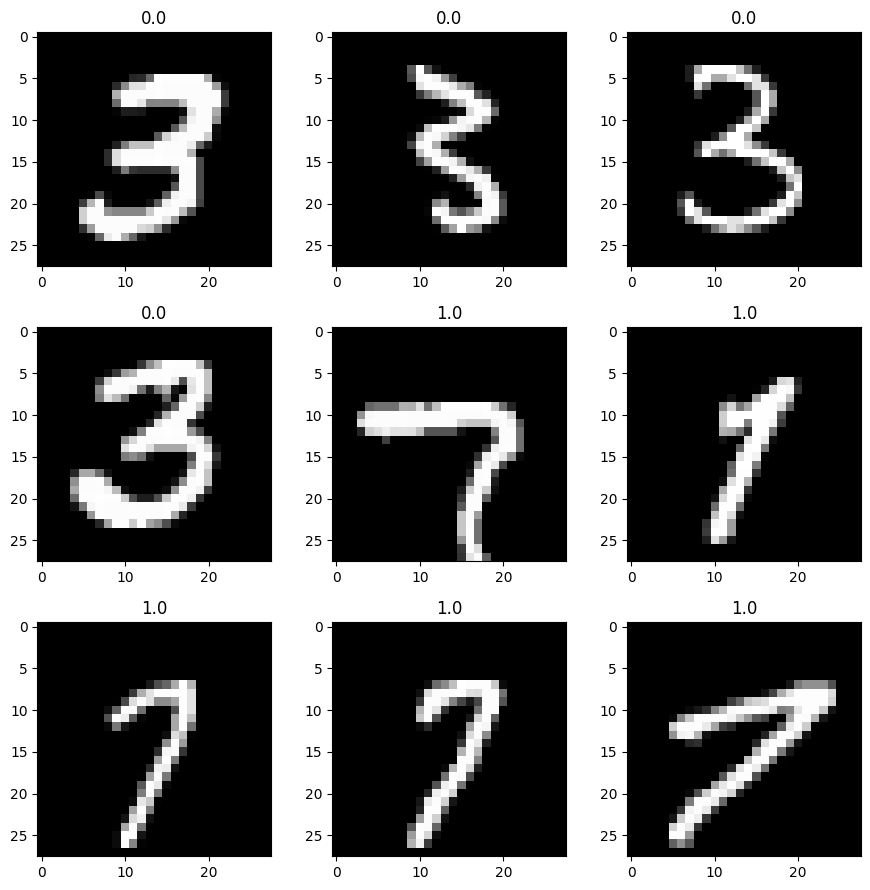

In [32]:
ds_check_indexes = [0, 1000, 5000, 5200, 6200, 11000, 12300, 12301, 12395]

plt.figure(figsize=(9, 9))

for i, index in enumerate(ds_check_indexes):
    plt.subplot(3, 3, i+1)
    plt.title(str(y_train_subset[index]))
    plt.imshow(X_train_subset[index].reshape(28, 28), cmap="gray")

plt.tight_layout()
plt.show()

## Eğitim ve Test Veri Setlerine Ayırma

Veri setimizi eğitim (%80) ve test (%20) alt kümelerine ayıralım. Test veri seti, modelimizin genelleme yeteneğini değerlendirmek için kullanılacaktır.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train_subset, y_train_subset, test_size=0.2, random_state=42)

Ayırma işleminin sonuçlarını kontrol edelim:

In [34]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(9916, 784) (9916,)
(2480, 784) (2480,)


## Lojistik Regresyon Modeli

### Sigmoid Fonksiyonu

Lojistik regresyon, doğrusal bir fonksiyon çıktısını 0-1 aralığında bir olasılık değerine dönüştürmek için sigmoid fonksiyonunu kullanır:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

Sigmoid fonksiyonu, herhangi bir reel sayıyı alır ve onu 0 ile 1 arasında bir değere sıkıştırır, bu da bir olasılık olarak yorumlanabilir.

In [42]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

### Lojistik Regresyon Sınıfı

Şimdi, lojistik regresyon algoritmasını gerçekleştiren bir sınıf tanımlayalım. Bu sınıf:

1. **init**: Öğrenme hızı ve iterasyon sayısı gibi hiperparametreleri başlatır
2. **fit**: Gradient descent ile modeli eğitir
3. **predict**: Eğitilmiş modeli kullanarak yeni örnekler için tahminler yapar

Kullanılan maliyet fonksiyonu, ikili çapraz entropi (binary cross entropy) fonksiyonudur:

$$ J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [ y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) ] $$

Burada $h_\theta(x) = \sigma(\theta^T x)$ olup, $\sigma$ sigmoid fonksiyonudur.

In [47]:
class LogisticRegression:
    def __init__(self, lr=0.001, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None

    def fit(self, X, y):
        num_samples, num_features = X.shape
        ones_column = np.ones((num_samples, 1))
        X = np.append(ones_column, X, axis=1)
        self.weights = np.zeros(num_features + 1)
        history = []

        # gradient descent
        for epoch in range(self.n_iters):
            linear_model = np.dot(X, self.weights)
            y_hat = sigmoid(linear_model)
            loss = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
            history.append(loss)

            dw = (1 / num_samples) * np.dot(X.T, (y_hat - y))
            self.weights = self.weights - (self.lr * dw)
            if (epoch + 1) % 50 == 0:
                print(f"e: {epoch + 1:04} \t loss: {loss}")

        return history

    def predict(self, X):
        num_samples, _ = X.shape
        ones_column = np.ones((num_samples, 1))
        X = np.append(ones_column, X, axis=1)

        linear_model = np.dot(X, self.weights)
        y_predicted = sigmoid(linear_model)
        y_predicted_classes = np.where(y_predicted > 0.5, 1, 0)
        return y_predicted_classes

### Doğruluk (Accuracy) Fonksiyonu

Model performansını değerlendirmek için doğruluk metriğini kullanacağız. Doğruluk, doğru tahmin edilen örneklerin toplam örnek sayısına oranıdır:

In [43]:
def accuracy(y_true, y_predicted):
    acc = np.sum(y_true == y_predicted) / len(y_predicted)
    return acc

## Model Eğitimi

Lojistik regresyon modelimizi oluşturalım ve eğitim veri seti üzerinde eğitelim:

e: 0050 	 loss: 0.6185270112451897
e: 0100 	 loss: 0.5568964846250115
e: 0150 	 loss: 0.506554142510564
e: 0200 	 loss: 0.46498210079688834
e: 0250 	 loss: 0.4302820688812886
e: 0300 	 loss: 0.40101217251696164
e: 0350 	 loss: 0.37607213000453804
e: 0400 	 loss: 0.3546178673739034
e: 0450 	 loss: 0.33599746022631116
e: 0500 	 loss: 0.3197033412121092
e: 0550 	 loss: 0.30533684831543645
e: 0600 	 loss: 0.2925819863151871
e: 0650 	 loss: 0.28118598058749983
e: 0700 	 loss: 0.27094480530347836
e: 0750 	 loss: 0.26169234867571806
e: 0800 	 loss: 0.2532922427505191
e: 0850 	 loss: 0.24563165397458156
e: 0900 	 loss: 0.23861652536459807
e: 0950 	 loss: 0.23216790086096048
e: 1000 	 loss: 0.2262190625505191


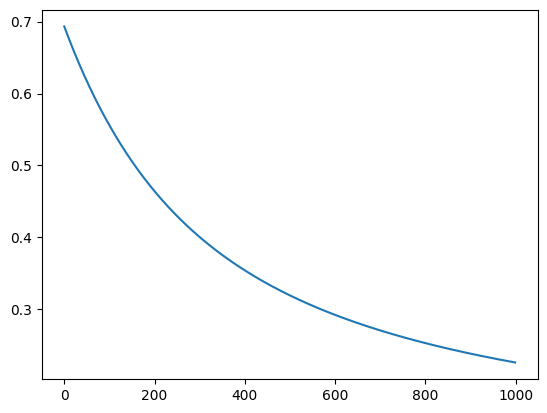

In [44]:
regressor = LogisticRegression(lr=0.001, n_iters=1000)
history = regressor.fit(X_train, y_train)
plt.plot(history)
plt.show()

## Model Değerlendirme

Eğitilmiş modelimizi test veri seti üzerinde değerlendirelim:

In [45]:
y_predictions = regressor.predict(X_test)
print(accuracy(y_test, y_predictions))

0.969758064516129


## Tahminlerin Görselleştirilmesi

Test veri setindeki ilk 9 örnek için tahminleri görselleştirelim. Başlıklar, modelimizin tahminleridir (0: rakam 3, 1: rakam 7):

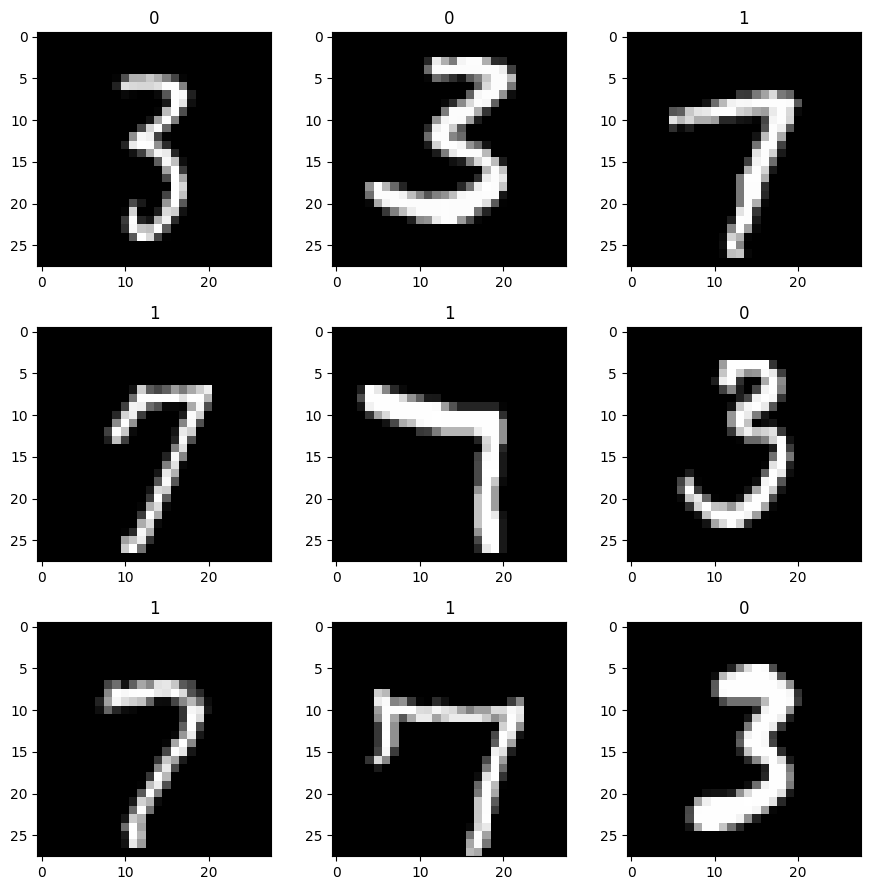

In [46]:
plt.figure(figsize=(9, 9))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.title(str(y_predictions[i]))
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

plt.tight_layout()
plt.show()